In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [2]:
df = pd.read_csv("Algerian_forest_fires_dataset_Cleaned.csv")
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
240,27,9,2012,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
241,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
242,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


In [3]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [4]:
df.drop(['day', 'month', 'year'],axis=1,inplace=True)


In [5]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [6]:
#Encoding
df["Classes"] = np.where(df["Classes"].str.contains('not fire'),0,1)


In [7]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [8]:
# Independent and dependent features 
x = df.drop("FWI",axis= 1)
y = df["FWI"]

In [9]:
#train Test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

<Axes: >

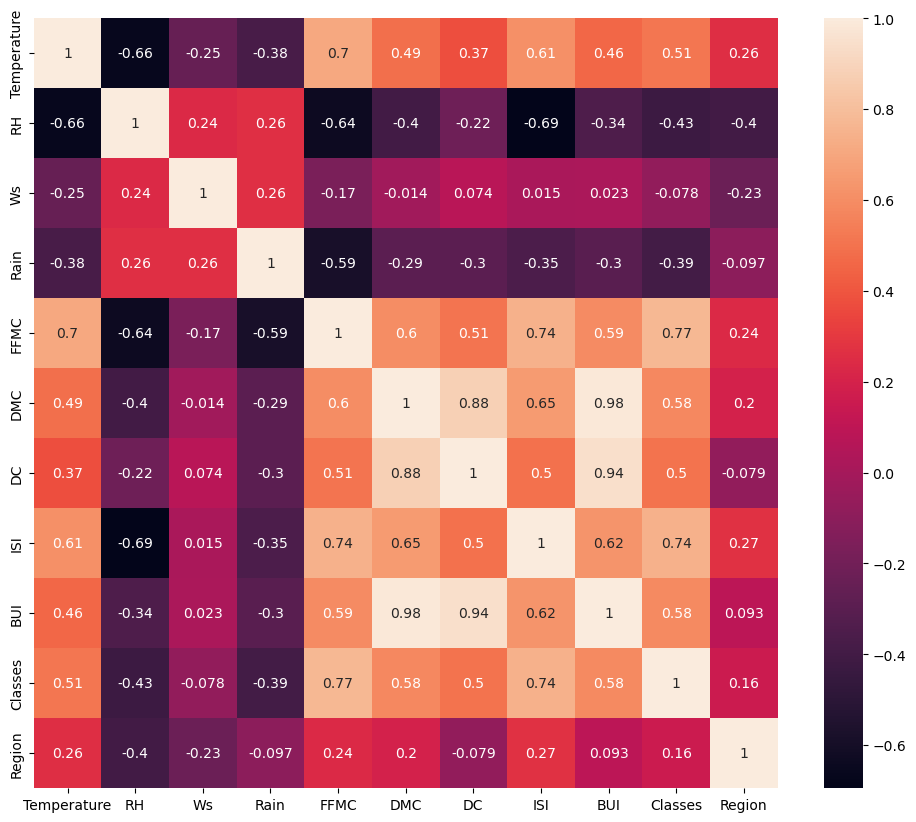

In [10]:
# Check coorelation
plt.figure(figsize=(12,10))
sns.heatmap(x_train.corr(),annot=True)



In [11]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: 
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [12]:
## threshold--Domain expertise
corr_features=correlation(x_train,0.85)

In [13]:
## drop features when correlation is more than 0.85 
x_train.drop(corr_features,axis=1,inplace=True)
x_test.drop(corr_features,axis=1,inplace=True)
x_train.shape,x_test.shape

((183, 9), (61, 9))

## Faeture Scaling or standardzation 

In [14]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

## Box Plot For undertanding 

Text(0.5, 1.0, 'X_train After Scaling')

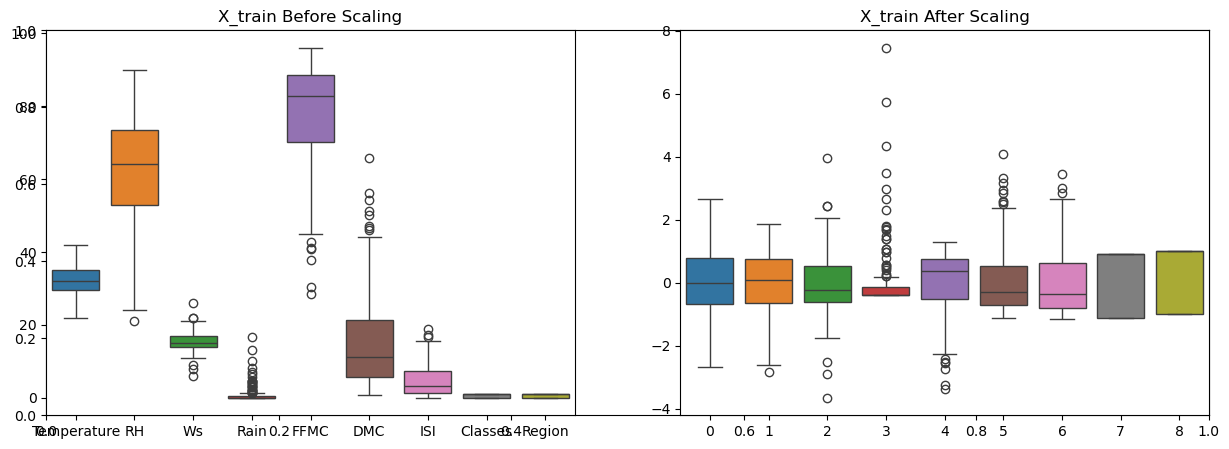

In [15]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=x_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=x_train_scaled)
plt.title('X_train After Scaling')

## Linear Reggresion Model 


mean_absolute_error : 0.6664617032747255
r2_score :  0.9869140740800542


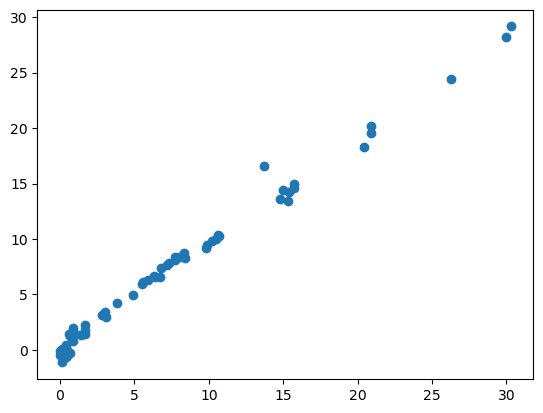

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , r2_score
linreg = LinearRegression()
linreg.fit(x_train_scaled,y_train)
y_pred = linreg.predict(x_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("mean_absolute_error :",mae)
print("r2_score : ",score)

plt.scatter(y_test,y_pred)


## Lasso Regression

mean_absolute_error : 1.2605401955498963
r2_score :  0.9467766860821712


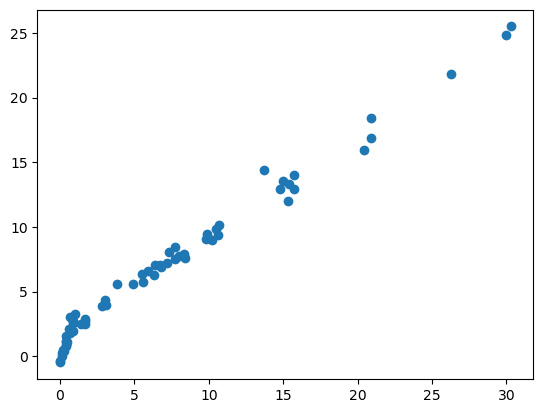

In [17]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error , r2_score
lasso = Lasso()
lasso.fit(x_train_scaled,y_train)
y_pred = lasso.predict(x_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("mean_absolute_error :",mae)
print("r2_score : ",score)

plt.scatter(y_test,y_pred)


## Lasso Cross Validation

In [18]:
from sklearn.linear_model import LassoCV


lassoCV= LassoCV(cv=5)
lassoCV.fit(x_train_scaled,y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [19]:
lassoCV.alpha_

np.float64(0.030489185052847537)

In [20]:
lassoCV.alphas_

array([6.56869579, 6.12598768, 5.71311662, 5.32807168, 4.96897748,
       4.63408503, 4.32176321, 4.03049083, 3.75884924, 3.50551538,
       3.26925538, 3.04891851, 2.8434316 , 2.65179383, 2.4730718 ,
       2.30639504, 2.15095173, 2.00598478, 1.87078812, 1.74470327,
       1.6271161 , 1.51745392, 1.41518261, 1.31980404, 1.23085366,
       1.14789825, 1.07053375, 0.99838335, 0.93109566, 0.86834293,
       0.80981952, 0.75524039, 0.70433972, 0.65686958, 0.61259877,
       0.57131166, 0.53280717, 0.49689775, 0.4634085 , 0.43217632,
       0.40304908, 0.37588492, 0.35055154, 0.32692554, 0.30489185,
       0.28434316, 0.26517938, 0.24730718, 0.2306395 , 0.21509517,
       0.20059848, 0.18707881, 0.17447033, 0.16271161, 0.15174539,
       0.14151826, 0.1319804 , 0.12308537, 0.11478982, 0.10705337,
       0.09983834, 0.09310957, 0.08683429, 0.08098195, 0.07552404,
       0.07043397, 0.06568696, 0.06125988, 0.05713117, 0.05328072,
       0.04968977, 0.04634085, 0.04321763, 0.04030491, 0.03758

In [21]:
lassoCV.mse_path_

array([[59.86837508, 43.11735707, 54.51759389, 73.14485419, 37.12765772],
       [54.31572421, 39.46569507, 49.88626377, 70.3378684 , 32.74212104],
       [48.98848492, 34.9503905 , 43.53419177, 64.37557408, 28.14353788],
       [43.67864733, 30.99670524, 38.00752157, 59.09677195, 24.19941194],
       [39.05005545, 27.53329193, 33.19899852, 54.41871129, 20.8423674 ],
       [35.01511463, 24.49793138, 29.01511889, 50.26899682, 17.99083924],
       [31.49693746, 21.83643498, 25.37463489, 44.52741573, 15.57438304],
       [28.42880745, 19.50155522, 22.20674923, 39.37483179, 13.53186331],
       [25.75265806, 17.45212939, 19.45025142, 34.86905529, 11.81093132],
       [23.4176579 , 15.65218259, 17.05152586, 30.92753112, 10.36578685],
       [21.38042723, 14.07042061, 14.96405755, 27.47829003,  9.1570282 ],
       [19.6023463 , 12.67952053, 13.14738439, 24.45863403,  8.15062046],
       [18.05007844, 11.45564443, 11.56614843, 21.81335227,  7.31703107],
       [16.69460107, 10.37799039, 10.1

mean_absolute_error : 0.7023895886240231
r2_score :  0.9858370744565005


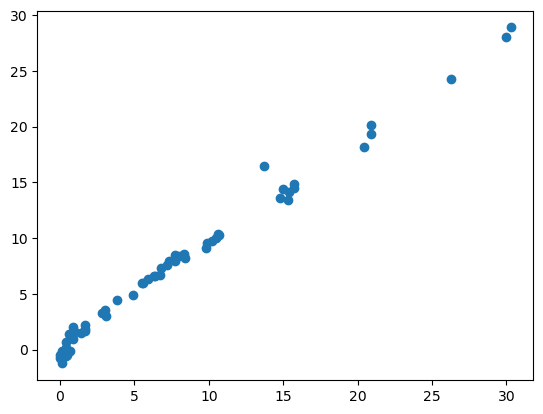

In [22]:
y_pred = lassoCV.predict(x_test_scaled)
plt.scatter(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("mean_absolute_error :",mae)
print("r2_score : ",score)


## Ridge Regreesion 

mean_absolute_error : 0.6883193873126452
r2_score :  0.9862237842436801


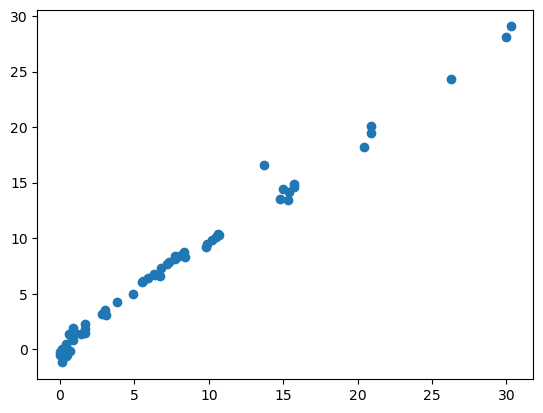

In [23]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error , r2_score
ridge= Ridge()
ridge.fit(x_train_scaled,y_train)
y_pred = ridge.predict(x_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("mean_absolute_error :",mae)
print("r2_score : ",score)

plt.scatter(y_test,y_pred)

# Ridge Cross validation 

mean_absolute_error : 0.6883193873126452
r2_score :  0.9862237842436801


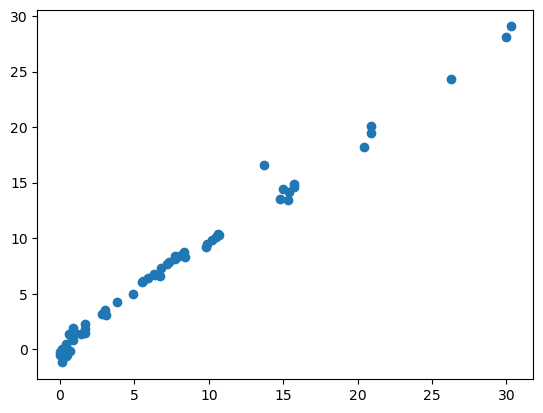

In [24]:
from sklearn.linear_model import RidgeCV


ridgeCV= RidgeCV(cv=5)
ridgeCV.fit(x_train_scaled,y_train)
y_pred = ridgeCV.predict(x_test_scaled)
plt.scatter(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("mean_absolute_error :",mae)
print("r2_score : ",score)

In [25]:
ridgeCV.alphas

(0.1, 1.0, 10.0)

In [26]:
ridgeCV.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

## ElasticNet Reggression

mean_absolute_error : 1.9220121398572438
r2_score :  0.8723294894980856


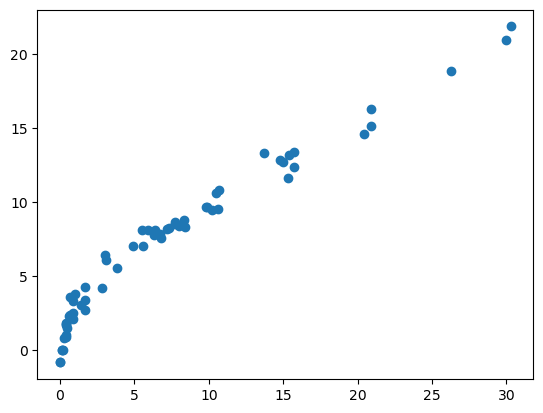

In [27]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error , r2_score
elasticNet= ElasticNet()
elasticNet.fit(x_train_scaled,y_train)
y_pred = elasticNet.predict(x_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("mean_absolute_error :",mae)
print("r2_score : ",score)

plt.scatter(y_test,y_pred)

## Lasso CV 

mean_absolute_error : 0.7023895886240231
r2_score :  0.9858370744565005


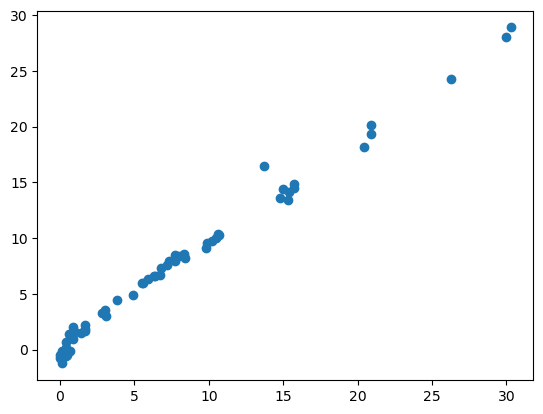

In [29]:
from sklearn.linear_model import LassoCV


lassoCV= LassoCV(cv=5)
lassoCV.fit(x_train_scaled,y_train)
y_pred = lassoCV.predict(x_test_scaled)
plt.scatter(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("mean_absolute_error :",mae)
print("r2_score : ",score)

In [ ]:
#picling the model 

In [30]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [33]:
ridge

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [34]:
import pickle
pickle.dump(scaler,open("scaler.pkl","wb"))
pickle.dump(ridge,open("ridge.pkl","wb"))
